# Notebook (prédiction de la demande en eau - données journalières)

## Importation des bibliothèques

In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

## Importation des données

In [2]:
data = pd.read_csv(r'c:\Users\ACER\Documents\Projet IA\Datasets\Parakou_Daily.csv', sep = ",")
data.head()
df = data.copy()

## Conversion de la date et renommage des colonnes

In [3]:
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')
df = df.rename(columns={
    "T2M_MAX":"Tmax",
    "T2M_MIN":"Tmin",
    "PRECTOTCORR":"Rain",
    "ALLSKY_SFC_SW_DWN":"Radiation",
    "QV2M":"QV"
})

## Visualisation et nettoyage des données

### Vérification des valeurs manquantes

In [4]:
df.dtypes

YEAR                  int64
DOY                   int64
Tmax                float64
Tmin                float64
Rain                float64
QV                  float64
Radiation           float64
DATE         datetime64[ns]
dtype: object

### Visualisation boxplot

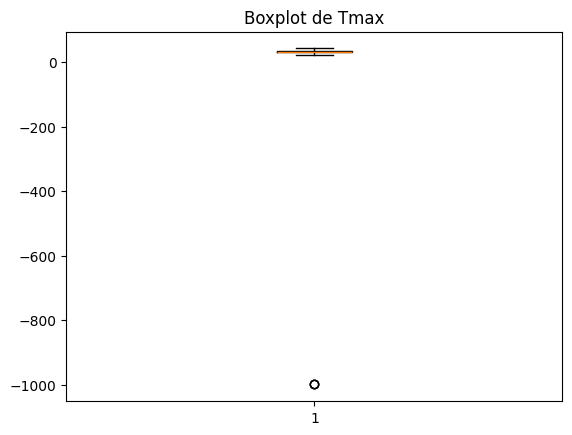

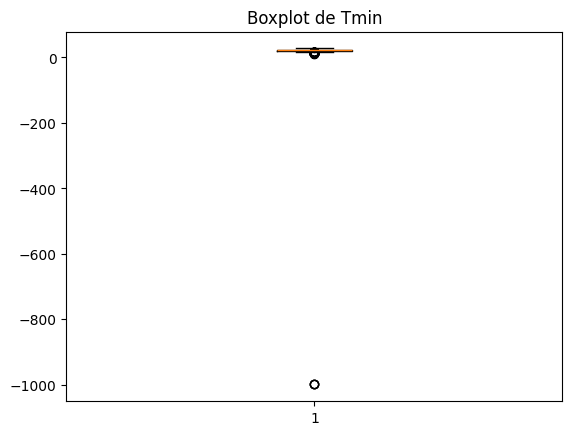

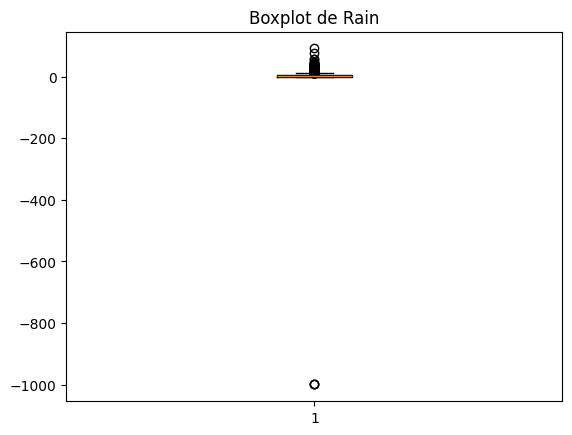

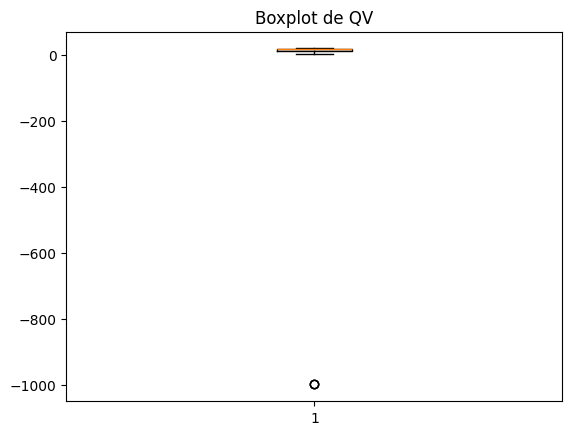

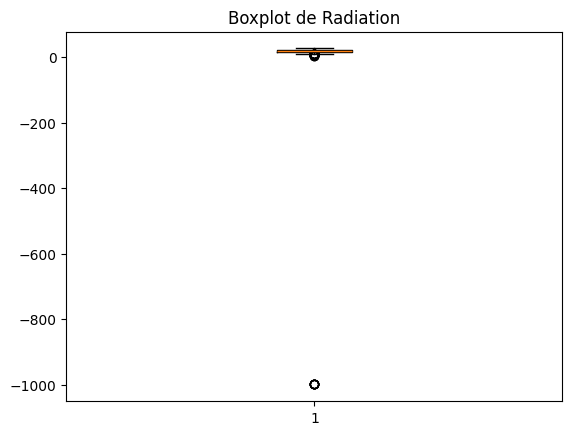

In [5]:
col = list(df.columns)
cols = col[2:7] 
for j in cols : 
    plt.boxplot(df[j])
    plt.title(f"Boxplot de {j}")
    plt.show()

### Imputation des valeurs aberrantes ( - 1000 pour diverses valeurs, c'est impossible au Bénin)

In [6]:
for p in cols : 
    df[p] = df[p].mask(df[p]<0) ##mettre NaN pour les valeurs aberrantes 
    df_clean = df.fillna(df[p].median()) ##interpoler pour les imputer

df_clean.describe()

,YEAR,DOY,Tmax,Tmin,Rain,QV,Radiation,DATE
count,2065.000000,2065.000000,2065.000000,2065.000000,2065.000000,2065.000000,2065.000000,2065
mean,2022.345763,175.858596,32.840114,21.360763,3.160153,14.542772,18.819019,2022-10-29 00:00:00
min,2020.000000,1.000000,19.605000,11.110000,0.000000,3.460000,4.130000,2020-01-01 00:00:00
25%,2021.000000,87.000000,29.940000,20.040000,0.000000,11.780000,16.720000,2021-05-31 00:00:00
50%,2022.000000,173.000000,32.590000,22.010000,0.640000,16.510000,19.605000,2022-10-29 00:00:00
75%,2024.000000,263.000000,35.520000,23.230000,4.100000,17.480000,21.350000,2024-03-28 00:00:00
max,2025.000000,366.000000,42.240000,27.170000,90.910000,19.605000,26.270000,2025-08-26 00:00:00
std,1.640265,103.957329,3.594791,2.806834,6.210926,4.023928,3.641935,NaN


In [7]:
df_clean.head()
new_col = list(df_clean.columns)
slic = new_col[2:7]
slic
df_clean.dtypes
print(df_clean.isna().sum())

YEAR         0
DOY          0
Tmax         0
Tmin         0
Rain         0
QV           0
Radiation    0
DATE         0
dtype: int64


### Boxplot après correction

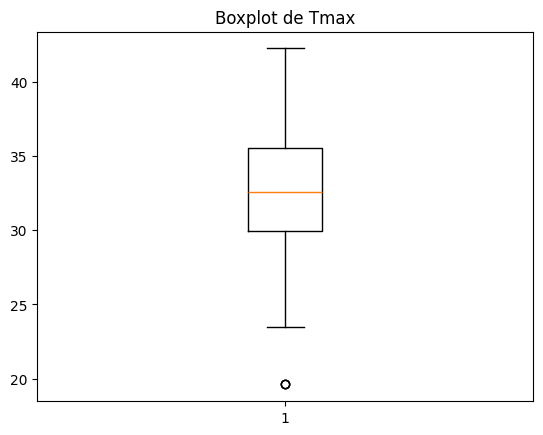

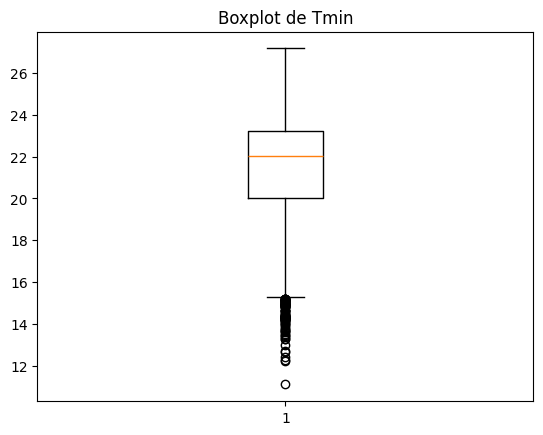

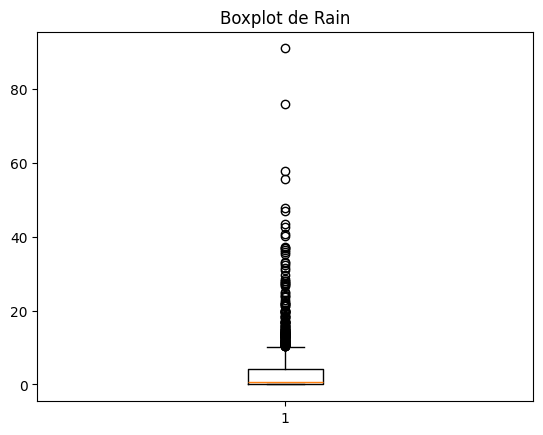

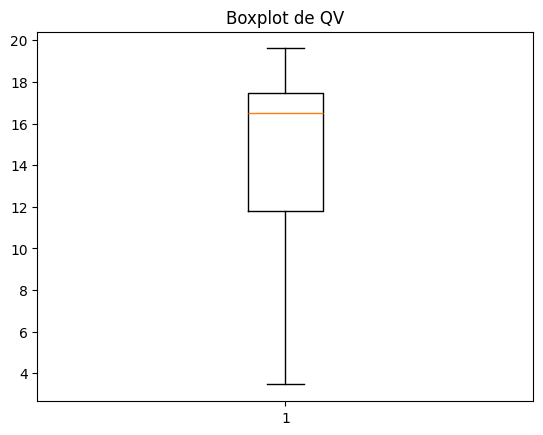

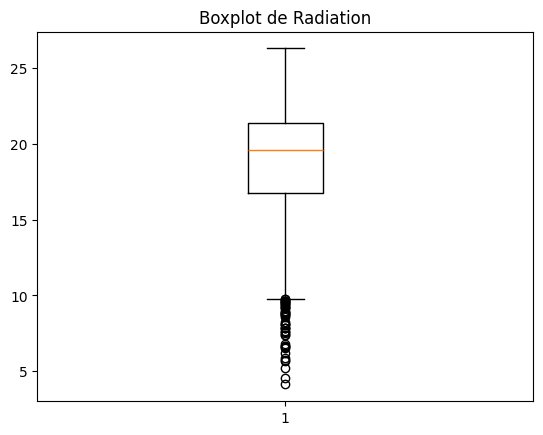

In [8]:
import seaborn as sns 
for j in cols : 
    plt.boxplot(df_clean[j])
    plt.title(f"Boxplot de {j}")
    plt.show()

## Préparation des données 

### Extraction des données (jour, mois, etc.) puis extraction de la base de données des périodes de cultures 
Ici, la culture est supposée être faite en contresaison. 

In [9]:
# Extraire l'année
df_clean['Year'] = df_clean['DATE'].dt.year
df_clean['Month'] = df_clean['DATE'].dt.month
df_clean['Day'] = df_clean['DATE'].dt.day
## Définition des périodes d'activité (culture)
filtre = ((df_clean['Year']>2020) & (df_clean['Month'].isin([1,2,3])) | 
          (df_clean['Year']>=2020) & (df_clean['Month'].isin([11,12])))
df_tomate = df_clean[filtre].copy()
df_tomate = df_tomate[~((df_tomate['Month']== 3)& (df_tomate['Day']>25))]

In [10]:
df_tomate = df_tomate.drop(['YEAR', 'DOY'], axis = 1) ##suppression des colonnes YEAR, DOY
df_tomate

,Tmax,Tmin,Rain,QV,Radiation,DATE,Year,Month,Day
305,32.71,18.85,0.00,13.38,22.48,2020-11-01,2020,11,1
306,32.34,19.02,0.00,14.24,18.71,2020-11-02,2020,11,2
307,32.81,19.90,0.00,14.91,20.48,2020-11-03,2020,11,3
308,32.14,20.33,0.00,15.40,18.95,2020-11-04,2020,11,4
309,28.71,20.72,0.00,14.78,19.55,2020-11-05,2020,11,5
...,...,...,...,...,...,...,...,...,...
1906,39.20,24.07,0.27,13.90,22.44,2025-03-21,2025,3,21
1907,39.76,24.74,0.05,14.91,20.92,2025-03-22,2025,3,22
1908,39.25,25.20,0.05,14.33,23.52,2025-03-23,2025,3,23
1909,38.20,24.83,0.02,14.45,20.15,2025-03-24,2025,3,24


## Feature engineering

### Calcul de la température, évapotranspiration avec la méthode Hargreaves et ETc (Kc_moyen = 0.85)

In [11]:
df_tomate['Tmean'] = (df_tomate['Tmax'] + df_tomate['Tmin']) / 2
df_tomate['ET0'] = 0.0023 * (df_tomate['Tmax'] - df_tomate['Tmin'])**0.5 * (df_tomate['Tmean'] + 17.8) * df_tomate['Radiation']
df_tomate['ETc'] = 0.85 * df_tomate['ET0']
df_tomate['Irr_mm'] = df_tomate['ETc'] - df_tomate['Rain']
df_tomate['Irr_mm']= df_tomate['Irr_mm'].apply(lambda x: max(0, x))
df_tomate.head(3)

,Tmax,Tmin,Rain,QV,Radiation,DATE,Year,Month,Day,Tmean,ET0,ETc,Irr_mm
305,32.71,18.85,0.0,13.38,22.48,2020-11-01,2020,11,1,25.780,8.388668,7.130367,7.130367
306,32.34,19.02,0.0,14.24,18.71,2020-11-02,2020,11,2,25.680,6.828782,5.804465,5.804465
307,32.81,19.90,0.0,14.91,20.48,2020-11-03,2020,11,3,26.355,7.473100,6.352135,6.352135


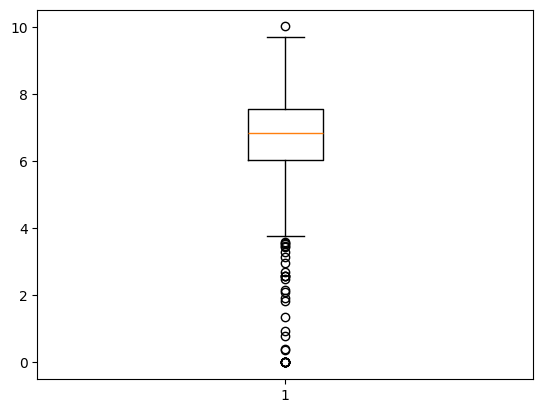

In [12]:
plt.boxplot(df_tomate['Irr_mm'])
plt.show()

## Préparation (machine learning)

### Scission de la base de données 

In [13]:
X = df_tomate[['Tmax', 'Tmin', 'Rain', 'QV', 'Radiation']]
y = df_tomate['Irr_mm']

## Preprocessing

In [14]:
##importation des bibliothèques 
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

##scission en jeux d'entrainement et de validation 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.80, shuffle = False, random_state= 42)

## Implémentation et entraînement du modèle Random Forest

In [15]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluation du modèle

In [16]:
## prédiction avec le modèle 
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

## comparaison (données d'entraînement)
mse1 = mean_squared_error(y_train, y_train_pred)
rmse1 = np.sqrt(mse1)
mae1 = mean_absolute_error(y_train, y_train_pred)
r21 = r2_score(y_train, y_train_pred)
print(f"Mean Squared Error for train: {round(mse1, 5)}")
print(f"Root Mean Squared Error for train: {round(rmse1,5)}")
print(f"R2 for train: {round(r21,5)}")
print(f"Root MAE for train: {round(mae1,5)}")

## comparaison (données de validation)
mse2 = mean_squared_error(y_test, y_test_pred)
rmse2 = np.sqrt(mse1)
mae2 = mean_absolute_error(y_test, y_test_pred)
r22 = r2_score(y_test, y_test_pred)
print(f"Mean Squared Error for validation: {round(mse2,5)}")
print(f"Root Mean Squared Error for validation: {round(rmse2,5)}")
print(f"R2 for validation : {round(r22,5)}")
print(f"Root MAE for validation: {round(mae2,5)}")

Mean Squared Error for train: 0.00889
Root Mean Squared Error for train: 0.09429
R2 for train: 0.99657
Root MAE for train: 0.06369
Mean Squared Error for validation: 0.06313
Root Mean Squared Error for validation: 0.09429
R2 for validation : 0.96071
Root MAE for validation: 0.18446


## Graphique 

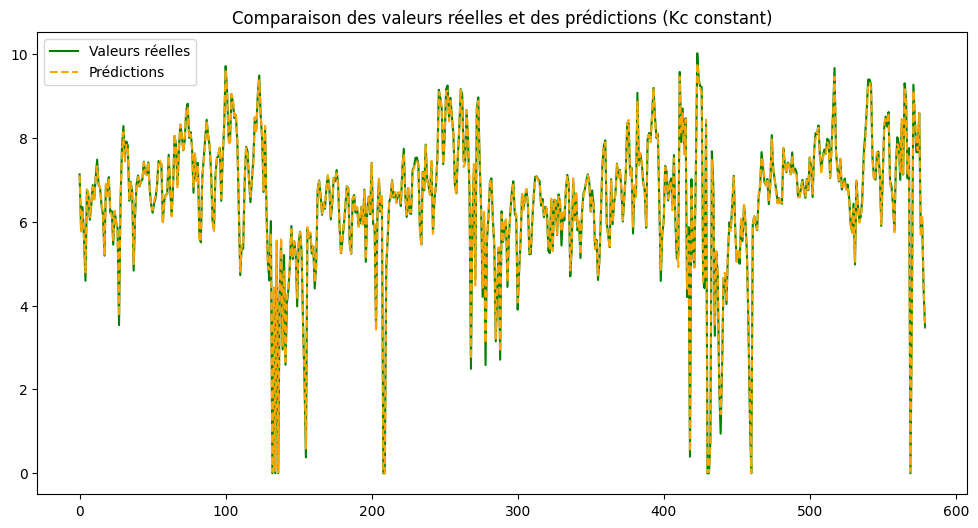

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(y_train.values, label='Valeurs réelles', color='green')
plt.plot(y_train_pred, label='Prédictions', color='orange', linestyle='--')
plt.title('Comparaison des valeurs réelles et des prédictions (Kc constant)')
plt.legend()
plt.show()

## Optimisation des hyperparamètres

In [19]:
## définition des paramètres 
param= {'n_estimators' : [100, 200, 300, 400], 
              'max_depth' : [None, 5, 10]}

## grille de recherche 
grid_search = GridSearchCV(estimator = rf, param_grid= param, error_score = 'raise')
## entrainement 
grid_search.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,n_estimators,200


## Récupération du meilleur modèle et entrainement

In [20]:
## les meilleurs paramètres et le scores obtenue 
print("Meilleurs hyperparamètres :", grid_search.best_params_)  ##meilleurs paramètres 
print("Meilleur score :", grid_search.best_score_)   ## meilleur score

##extraction du meilleur modèle et évaluation
best = grid_search.best_estimator_  ##extraction du modèle 
y_opt_pred = best.predict(X_train) ##évaluation données d'entrainement
y_val_pred = best.predict(X_test) ##évaluation données de validation 

##métriques de performances (données d'entraînement)
mse_opt = mean_squared_error(y_train, y_opt_pred)
rmse_opt = np.sqrt(mse_opt)
mae_opt = mean_absolute_error(y_train, y_opt_pred)
r2_opt = r2_score(y_train, y_opt_pred)
print(f"Mean Squared Error for train after optimisation : {round(mse_opt,5)}")
print(f"Root Mean Squared Error for train after optimisation : {round(rmse_opt, 5)}")
print(f"MAE for train after optimisation : {round(mae_opt,5)}")
print(f"R² for train after optimisation : {round(r2_opt, 5)}")

## métriques de performances (données de validation)
mse_val_opt = mean_squared_error(y_test, y_val_pred)
rmse_val_opt = np.sqrt(mse_val_opt)
mae_val_opt = mean_absolute_error(y_test, y_val_pred)
r2_val_opt = r2_score(y_test, y_val_pred)
print(f"Mean Squared Error for validation after optimisation : {round(mse_val_opt,5)}")
print(f"Root Mean Squared Error for validation after optimisation : {round(rmse_val_opt, 5)}")
print(f"MAE for validation after optimisation : {round(mae_val_opt ,5)}")
print(f"R² for validation after optimisation : {round(r2_val_opt, 5)}")

Meilleurs hyperparamètres : {'max_depth': None, 'n_estimators': 200}
Meilleur score : 0.9586226906984712
Mean Squared Error for train after optimisation : 0.00917
Root Mean Squared Error for train after optimisation : 0.09575
MAE for train after optimisation : 0.06336
R² for train after optimisation : 0.99646
Mean Squared Error for validation after optimisation : 0.05951
Root Mean Squared Error for validation after optimisation : 0.24395
MAE for validation after optimisation : 0.17516
R² for validation after optimisation : 0.96297


## Graphique (données test)

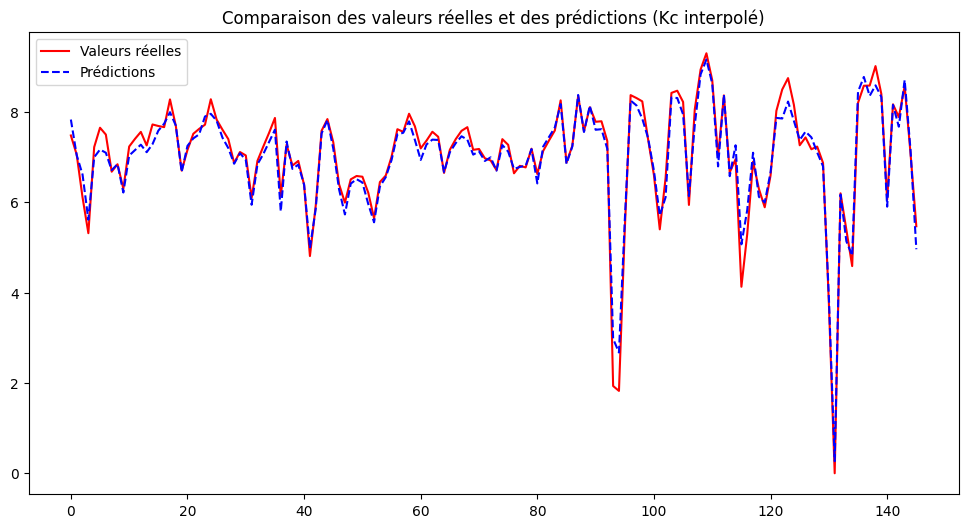

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Valeurs réelles', color='red')
plt.plot(y_val_pred, label='Prédictions', color='blue', linestyle='--')
plt.title('Comparaison des valeurs réelles et des prédictions (Kc interpolé)')
plt.legend()
plt.show()

## Intégration du Kc comme features

### Fonction d'attribution des Kc

In [22]:
import numpy as np
import pandas as pd

def kc_curve():
    # Phases (durées en jours)
    initial, development, mid, late = 30, 40, 45, 30
    kc_initial, kc_mid, kc_late = 0.60, 1.15, 0.80
    
     # Initial
    kc_init = np.full(initial, kc_initial)
    
    # Development (interpolation)
    kc_dev = np.linspace(kc_initial, kc_mid, development)
    
    # Mid-season (plateau)
    kc_mid_season = np.full(mid, kc_mid)
    
    # Late season (interpolation)
    kc_late_season = np.linspace(kc_mid, kc_late, late)
    
    # Concatenation de toutes les phases
    kc_values = np.concatenate([kc_init, kc_dev, kc_mid_season, kc_late_season])
    kc_df = pd.Series(kc_values, name="Kc").reset_index()
    kc_df.columns = ['Jour_culture', 'Kc']
    return kc_df

# Exemple d'application
kc_series = kc_curve()
annees = [2020, 2021, 2022, 2023, 2024]
kc_all = pd.concat([kc_series.assign(Year = a) for a in annees])

### Application 

In [23]:
df_tomate['Jour_culture'] = df_tomate.groupby("Year").cumcount()+1 
df_tomate.head(3)

,Tmax,Tmin,Rain,QV,Radiation,DATE,Year,Month,Day,Tmean,ET0,ETc,Irr_mm,Jour_culture
305,32.71,18.85,0.0,13.38,22.48,2020-11-01,2020,11,1,25.780,8.388668,7.130367,7.130367,1
306,32.34,19.02,0.0,14.24,18.71,2020-11-02,2020,11,2,25.680,6.828782,5.804465,5.804465,2
307,32.81,19.90,0.0,14.91,20.48,2020-11-03,2020,11,3,26.355,7.473100,6.352135,6.352135,3


### Fusion des bases de données

In [24]:
df_essai = df_tomate.merge(kc_all, on = ['Year', 'Jour_culture'], how = "left")
df_essai['Kc'] = df_essai['Kc'].fillna(method = 'ffill')
print(df_essai.isna().sum())

Tmax            0
Tmin            0
Rain            0
QV              0
Radiation       0
DATE            0
Year            0
Month           0
Day             0
Tmean           0
ET0             0
ETc             0
Irr_mm          0
Jour_culture    0
Kc              0
dtype: int64


C:\Users\ACER\AppData\Local\Temp\ipykernel_11320\2649860754.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_essai['Kc'] = df_essai['Kc'].fillna(method = 'ffill')


### Mise à jour des colonnes 

In [25]:
df_essai['ETc'] = df_essai['ET0'] * df_essai['Kc']
df_essai['Irr_mm'] = df_essai['ETc'] - df_essai['Rain']
df_essai['Irr_mm'] = df_essai['Irr_mm'].apply(lambda x: max(0, x))
df_essai.head(2)

,Tmax,Tmin,Rain,QV,Radiation,DATE,Year,Month,Day,Tmean,ET0,ETc,Irr_mm,Jour_culture,Kc
0,32.71,18.85,0.0,13.38,22.48,2020-11-01,2020,11,1,25.78,8.388668,5.033201,5.033201,1,0.6
1,32.34,19.02,0.0,14.24,18.71,2020-11-02,2020,11,2,25.68,6.828782,4.097269,4.097269,2,0.6


### Pre processing (machine learning)

In [26]:
##scission
X1 = df_essai[['Tmax', 'Tmin', 'Rain', 'QV', 'Radiation', 'Kc']]
y1 = df_essai['Irr_mm']

## données de test et validation 
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, train_size = 0.8, shuffle = False)

### Entrainement et évaluation du modèle 

In [27]:
rf.fit(X1_train, y1_train) ## entrainement 

## prédiction avec le modèle 
y1_train_pred = rf.predict(X1_train)
y1_test_pred = rf.predict(X1_test)

## comparaison (données d'entraînement)
mse1 = mean_squared_error(y1_train, y1_train_pred)
rmse1 = np.sqrt(mse1)
mae1 = mean_absolute_error(y1_train, y1_train_pred)
r21 = r2_score(y1_train, y1_train_pred)
print(f"Mean Squared Error for train: {round(mse1, 5)}")
print(f"Root Mean Squared Error for train: {round(rmse1,5)}")
print(f"R2 for train: {round(r21,5)}")
print(f"Root MAE for train: {round(mae1,5)}")

## comparaison (données de validation)
mse2 = mean_squared_error(y1_test, y1_test_pred)
rmse2 = np.sqrt(mse1)
mae2 = mean_absolute_error(y1_test, y1_test_pred)
r22 = r2_score(y1_test, y1_test_pred)
print(f"Mean Squared Error for validation: {round(mse2,5)}")
print(f"Root Mean Squared Error for validation: {round(rmse2,5)}")
print(f"R2 for validation : {round(r22,5)}")
print(f"Root MAE for validation: {round(mae2,5)}")

Mean Squared Error for train: 0.02391
Root Mean Squared Error for train: 0.15463
R2 for train: 0.99476
Root MAE for train: 0.10715
Mean Squared Error for validation: 0.63025
Root Mean Squared Error for validation: 0.15463
R2 for validation : 0.80891
Root MAE for validation: 0.55905


### Graphique

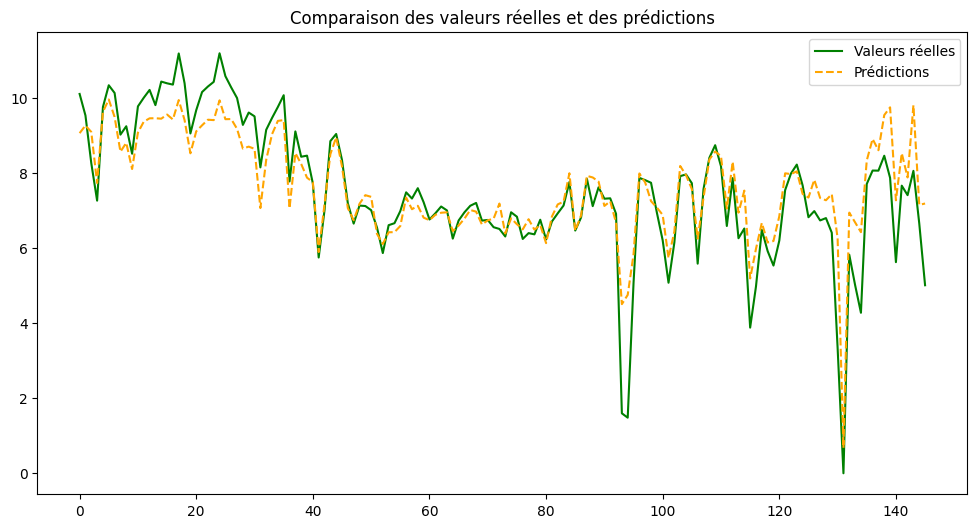

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(y1_test.values, label='Valeurs réelles', color='green')
plt.plot(y1_test_pred, label='Prédictions', color='orange', linestyle='--')
plt.title('Comparaison des valeurs réelles et des prédictions')
plt.legend()
plt.show()

### Essai des modèles AdaBoost et Gradient Boost

In [29]:
from sklearn.ensemble import GradientBoostingRegressor , AdaBoostRegressor 
m1 = AdaBoostRegressor(n_estimators = 100, learning_rate = 1.0, random_state = 42)
m2 = GradientBoostingRegressor(n_estimators = 100, learning_rate = 1.0, max_depth = 3, random_state = 42)

##entrainement
m1.fit(X1_train, y1_train)
m2.fit(X1_train, y1_train)

##prédiction
y_pred1 = m1.predict(X1_test)
y_pred2 = m2.predict(X1_test)

##évaluation 
mse_m1 = mean_squared_error(y1_test, y_pred1)
r2_m1 = r2_score(y1_test, y_pred1)
rmse_m1 = np.sqrt(mse_m1)

mse_m2 = mean_squared_error(y1_test, y_pred2)
r2_m2 = r2_score(y1_test, y_pred2)
rmse_m2 = np.sqrt(mse_m2)

if rmse_m2 < rmse_m1 : 
    print(f"Le modèle 2 est meilleur que le modèle 1. Meilleur RMSE : {round(rmse_m2, 5)}")
else : 
    print(f"Le modèle 1 est meilleur que le modèle 1. Meilleur RMSE : {round(rmse_m1, 5)}")

Le modèle 2 est meilleur que le modèle 1. Meilleur RMSE : 0.71936


### Optimisation du modèle Random Forest

In [30]:
## définition des paramètres 
param= {'n_estimators' : [100, 200, 300, 400], 
              'max_depth' : [None, 5, 10]}

## grille de recherche 
grid_search = GridSearchCV(estimator = rf, param_grid= param, error_score = 'raise', cv = 5)
## entrainement 
grid_search.fit(X1_train, y1_train)

## les meilleurs paramètres et le scores obtenue 
print("Meilleurs hyperparamètres :", grid_search.best_params_)  ##meilleurs paramètres 
print("Meilleur score :", grid_search.best_score_)   ## meilleur score

##extraction du meilleur modèle et évaluation
best = grid_search.best_estimator_  ##extraction du modèle 
y_val_pred = best.predict(X1_test) ##évaluation données de validation 


## métriques de performances (données de validation)
mse_val_opt = mean_squared_error(y1_test, y_val_pred)
rmse_val_opt = np.sqrt(mse_val_opt)
mae_val_opt = mean_absolute_error(y1_test, y_val_pred)
r2_val_opt = r2_score(y1_test, y_val_pred)
print(f"Mean Squared Error for validation after optimisation : {round(mse_val_opt,5)}")
print(f"Root Mean Squared Error for validation after optimisation : {round(rmse_val_opt, 5)}")
print(f"MAE for validation after optimisation : {round(mae_val_opt ,5)}")
print(f"R² for validation after optimisation : {round(r2_val_opt, 5)}")

Meilleurs hyperparamètres : {'max_depth': None, 'n_estimators': 400}
Meilleur score : 0.9238086017917915
Mean Squared Error for validation after optimisation : 0.61252
Root Mean Squared Error for validation after optimisation : 0.78264
MAE for validation after optimisation : 0.55652
R² for validation after optimisation : 0.81429


### Graphique 

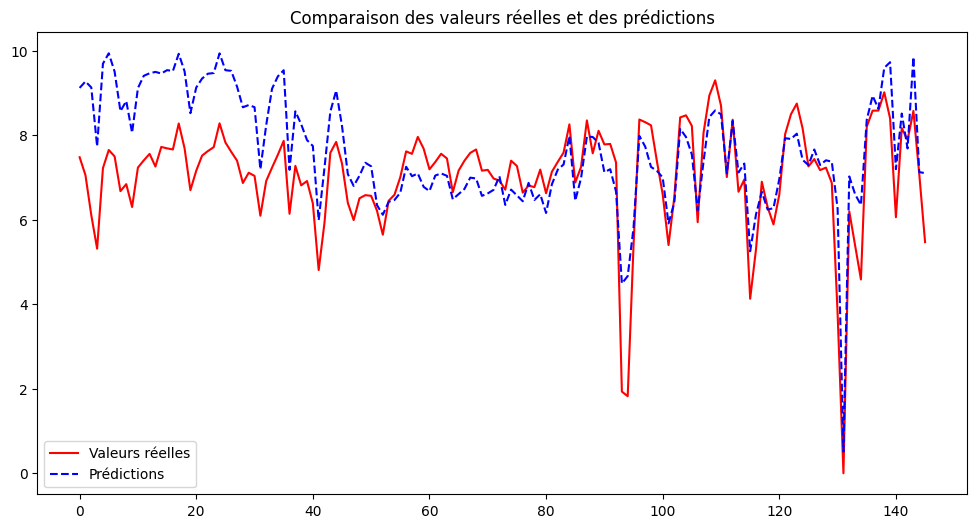

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Valeurs réelles', color='red')
plt.plot(y_val_pred, label='Prédictions', color='blue', linestyle='--')
plt.title('Comparaison des valeurs réelles et des prédictions')
plt.legend()
plt.show()